# **PRACTICA 4.- Modelación no supervisada**

## **Paso 1 Extraer los datos abiertos de ECOBICI, desde 2010-2025 descargar toda la data y juntarla toda en un dataframe son entre 90-100 millones de registros**

### **Para este primer paso descargue cada archivo se implemento un programa el cual le pasabamos los archivos y aqui se hacia el proceso de limpieza de los datos(Eliminar las columnas de fechas ya que estas no eran necesarias e iban a ocupara mas espacio, se modifico el tipo de dato de Genero_Usuario a enteros para reducir espacio de memoria siendo 0=F y 1=M, ademas corregimos unos valores numericos que eran del tipo 001 para dejarlo como 1 ya que nos generaba errores ya que python lo marcaba como tener varios tipos de dato en una misma tabla y por ultimo para los casos en que teniamos datos tipo 123-125 se opto por por dejar solo el primer dato, es decir 123 para evitar mas problemas, ademas le pregunte a Ecobici que representaban y dijeron que el primero era el nombre del modulo y el segundo la estacion, por eso se tomo esa decision, una vez que se limpiaban los archivos estos se unian todos en un csv, por el momento puse el ejemplo con dos archivos, pero este procedimiento se aplico a los 180 archivos para juntarlos en uno solo**

In [1]:
import pandas as pd
import numpy as np
import os
from tkinter import Tk
from tkinter.filedialog import askopenfilenames
import re
from datetime import datetime

def select_csv_files():
    """
    para abrir multiples archivos
    """
    Tk().withdraw()  # Hide the main tkinter window
    file_paths = askopenfilenames(
        title="Seleccione los archivos CSV a procesar",
        filetypes=[("Archivos CSV", "*.csv"), ("Todos los archivos", "*.*")]
    )
    return file_paths

def extract_date_from_filename(filename):
    """
    extrae el año y mes de cada archivo
    """
    try:
        base = os.path.basename(filename).split('.')[0]
        year, month = map(int, base.split('-'))
        return datetime(year=year, month=month, day=1)
    except:
        return datetime.min  # For files with invalid names

def analyze_csv(file_path):
    """
    Analiza el csv
    """
    if not file_path:
        print("No se seleccionó ningún archivo.")
        return None
    
    try:
        # Read the CSV file
        df = pd.read_csv(file_path)
        
        # Display basic information
        print(f"\n===== INFORMACIÓN DEL ARCHIVO =====")
        print(f"Archivo: {os.path.basename(file_path)}")
        print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
        
        # Display column names
        print("\n----- Nombres de columnas -----")
        for i, col in enumerate(df.columns):
            print(f"{i+1}. {col}")
        
        # Display data types and null counts
        print("\n----- Tipos de datos y valores nulos -----")
        for col in df.columns:
            null_count = df[col].isna().sum()
            null_percent = (null_count / len(df)) * 100
            print(f"{col}: Tipo={df[col].dtype}, Nulos={null_count} ({null_percent:.2f}%)")
        
        # Show random sample of data
        print("\n----- Muestra aleatoria de datos (5 registros) -----")
        print(df.sample(5, random_state=42))
        
        return df
    
    except Exception as e:
        print(f"Error al leer el archivo: {e}")
        return None

def rename_columns(df):
    """
    renombramos las columnas ya que algunos archivos tienen una nomeclatura distinta
    """
    columnas_correctas = [
        "Genero_Usuario", "Edad_Usuario", "Bici",
        "Ciclo_Estacion_Retiro", "Fecha_Retiro", "Hora_Retiro",
        "Ciclo_Estacion_Arribo", "Fecha_Arribo", "Hora_Arribo"
    ]
    
    # Check if there are extra columns
    if len(df.columns) > len(columnas_correctas):
        print(f"\nADVERTENCIA: El archivo tiene {len(df.columns)} columnas. Eliminando las columnas adicionales...")
        # Keep only the first n columns that match our expected structure
        df = df.iloc[:, :len(columnas_correctas)]
    
    # Rename columns
    df.columns = columnas_correctas[:len(df.columns)]
    
    print("\n----- Columnas renombradas -----")
    for i, col in enumerate(df.columns):
        print(f"{i+1}. {col}")
    
    return df

def clean_station_ids(value):
    """
    se limpuano los id para evitar nulos, 002 o casos de 123-123
    """
    if pd.isna(value) or value == "" or value is None:
        return -1
    
    # Convert to string if it's not already
    str_value = str(value).strip()
    
    # Handle empty strings
    if str_value == "":
        return -1
    
    # Check for hyphenated values (e.g., "107-108")
    if "-" in str_value:
        parts = str_value.split("-")
        for part in parts:
            if part.strip().isdigit():
                return int(part.strip())
        return -1
    
    # Try to convert to integer
    try:
        return int(float(str_value))  # Handle float strings
    except (ValueError, TypeError):
        # If conversion fails, try to extract numbers from string
        numbers = re.findall(r'\d+', str_value)
        if numbers:
            return int(numbers[0])
        return -1

def clean_bike_ids(value):
    """
    se limpian id de bicis de los casos null o 002 
    """
    if pd.isna(value) or value == "" or value is None:
        return -1
    
    # Convert to string if it's not already
    str_value = str(value).strip()
    
    # Handle empty strings or "Temporal"
    if str_value == "" or str_value.lower() == "temporal":
        return -1
    
    # Try to convert to integer
    try:
        return int(float(str_value))  # Handle float strings
    except (ValueError, TypeError):
        # If conversion fails but value exists, return original value
        return str_value

def clean_gender(df):
    """
    se convierten a valores numericos los generos para reducir memoria
    """
    # Create a copy to avoid SettingWithCopyWarning
    df = df.copy()
    
    # Primero llenamos nulos con la moda
    mode_gender = df["Genero_Usuario"].mode()[0]
    df.loc[df["Genero_Usuario"].isna(), "Genero_Usuario"] = mode_gender
    
    # Convertimos a string y limpiamos los valores
    gender_series = df["Genero_Usuario"].astype(str).str.strip().str.upper()
    
    # Mapeamos los valores a numéricos
    gender_map = {
        'F': 0,
        'M': 1
    }
    
    # Aplicamos el mapeo y asignamos 2 a cualquier otro valor
    df["Genero_Usuario"] = gender_series.map(lambda x: gender_map.get(x, 2))
    
    # Mostramos estadísticas de la conversión
    print("\nDistribución de valores de género después de la limpieza:")
    print(df["Genero_Usuario"].value_counts().sort_index())
    print("0: Femenino, 1: Masculino, 2: Otro/Desconocido")
    
    return df

def clean_age(df):
    """
    si hay nulo se toma la media 
    """
    median_age = df["Edad_Usuario"].median()
    df = df.copy()
    df.loc[df["Edad_Usuario"].isna(), "Edad_Usuario"] = median_age
    return df

def clean_data(df):
    """
    se limpia toodo
    """
    print("\n===== LIMPIANDO DATOS =====")
    
    # Create a copy to avoid modifying the original during iteration
    cleaned_df = df.copy()
    
    # Clean station IDs - only for truly problematic values
    print("Limpiando IDs de estación...")
    cleaned_df["Ciclo_Estacion_Retiro"] = cleaned_df["Ciclo_Estacion_Retiro"].apply(
        lambda x: clean_station_ids(x) if pd.isna(x) or str(x).strip() == "" or not str(x).isdigit() else int(float(x)))
    cleaned_df["Ciclo_Estacion_Arribo"] = cleaned_df["Ciclo_Estacion_Arribo"].apply(
        lambda x: clean_station_ids(x) if pd.isna(x) or str(x).strip() == "" or not str(x).isdigit() else int(float(x)))
    
    # Clean bike IDs - preserve original values unless truly invalid
    print("Limpiando IDs de bicicleta...")
    cleaned_df["Bici"] = cleaned_df["Bici"].apply(
        lambda x: clean_bike_ids(x) if pd.isna(x) or str(x).strip() == "" else x)
    
    # Handle gender nulls
    print("Gestionando valores nulos de género...")
    cleaned_df = clean_gender(cleaned_df)
    
    # Handle age nulls
    print("Gestionando valores nulos de edad...")
    cleaned_df = clean_age(cleaned_df)
    
    # Drop rows with null dates or times
    print("Eliminando filas con fechas o horas nulas...")
    before_rows = len(cleaned_df)
    
    cleaned_df = cleaned_df.dropna(subset=["Fecha_Retiro", "Fecha_Arribo", "Hora_Retiro", "Hora_Arribo"])
    
    after_rows = len(cleaned_df)
    dropped_rows = before_rows - after_rows
    print(f"Se eliminaron {dropped_rows} filas con fechas o horas nulas ({dropped_rows/before_rows*100:.2f}% del total)")
    
    # Remove date columns after cleaning (keeping only time columns)
    print("\nEliminando columnas de fecha (conservando solo las horas)...")
    cleaned_df = cleaned_df.drop(columns=["Fecha_Retiro", "Fecha_Arribo"], errors="ignore")
    
    return cleaned_df

def check_cleaning_results(original_df, cleaned_df):
    
    print("\n===== RESULTADOS DE LIMPIEZA =====")
    
    # Compare dimensions
    print(f"Filas originales: {len(original_df)}, Filas después de limpieza: {len(cleaned_df)}")
    
    # Check for null values in cleaned data
    null_counts = cleaned_df.isna().sum()
    if null_counts.sum() > 0:
        print("\nADVERTENCIA: Todavía hay valores nulos en los datos:")
        for col, count in null_counts.items():
            if count > 0:
                print(f"  - {col}: {count} valores nulos")
    else:
        print("\nÉxito: No hay valores nulos en los datos limpios")
    
    # Display sample of cleaned data
    print("\n----- Muestra de datos limpios (5 registros) -----")
    print(cleaned_df.sample(5, random_state=42))
    
    return null_counts.sum() == 0  # Return True if no nulls

def save_cleaned_data(cleaned_df, original_file_path):
    """
    guarda cada archivo pero con el sufijo clean
    """
    file_name, file_ext = os.path.splitext(original_file_path)
    cleaned_file_path = f"{file_name}_Clean{file_ext}"
    
    cleaned_df.to_csv(cleaned_file_path, index=False)
    print(f"\nDatos limpios guardados en: {cleaned_file_path}")
    return cleaned_file_path

def combine_dataframes(file_paths):
    """
    Combina los archivos limpiados
    """
    cleaned_dfs = []
    
    for file_path in file_paths:
        clean_path = f"{os.path.splitext(file_path)[0]}_Clean.csv"
        if os.path.exists(clean_path):
            df = pd.read_csv(clean_path)
            cleaned_dfs.append((extract_date_from_filename(clean_path), df))
    
    if not cleaned_dfs:
        print("\nNo se encontraron archivos limpios para combinar.")
        return None
    
    # Sort by date and combine
    cleaned_dfs.sort(key=lambda x: x[0])
    combined_df = pd.concat([df for (date, df) in cleaned_dfs], ignore_index=True)
    
    # Save combined file
    combined_path = "datos_combinados.csv"
    combined_df.to_csv(combined_path, index=False)
    print(f"\n===== ARCHIVOS COMBINADOS =====")
    print(f"Se combinaron {len(cleaned_dfs)} archivos en: {combined_path}")
    print(f"Dimensiones finales: {combined_df.shape[0]} filas x {combined_df.shape[1]} columnas")
    
    return combined_path

def process_file(file_path):
    """
    nos da un vistazo a las columnas
    """
    print(f"\n=== PROCESANDO ARCHIVO: {os.path.basename(file_path)} ===")
    
    # Analyze CSV
    original_df = analyze_csv(file_path)
    if original_df is None:
        return False
    
    # Rename columns
    df = rename_columns(original_df)
    
    # Clean data - with more conservative approach
    cleaned_df = clean_data(df)
    
    # Check results
    success = check_cleaning_results(original_df, cleaned_df)
    
    # Save cleaned data
    if success:
        save_cleaned_data(cleaned_df, file_path)
    else:
        print("\nADVERTENCIA: La limpieza no eliminó todos los valores nulos.")
        save_anyway = input("¿Desea guardar el archivo de todos modos? (s/n): ")
        if save_anyway.lower() == 's':
            save_cleaned_data(cleaned_df, file_path)
    
    return True

def main():
    print("=== LIMPIADOR DE DATOS DE BICICLETAS ===")
    print("Seleccione uno o más archivos CSV para procesar...")
    
    # Select files
    file_paths = select_csv_files()
    if not file_paths:
        return
    
    # Process each file
    for file_path in file_paths:
        process_file(file_path)
    
    # Combine cleaned files
    combine_dataframes(file_paths)

if __name__ == "__main__":
    main()

=== LIMPIADOR DE DATOS DE BICICLETAS ===
Seleccione uno o más archivos CSV para procesar...

=== PROCESANDO ARCHIVO: 2010-02.csv ===

===== INFORMACIÓN DEL ARCHIVO =====
Archivo: 2010-02.csv
Dimensiones: 1057 filas x 9 columnas

----- Nombres de columnas -----
1. Genero_Usuario
2. Edad_Usuario
3. Bici
4. Ciclo_Estacion_Retiro
5. Fecha_Retiro
6. Hora_Retiro
7. Ciclo_Estacion_Arribo
8. Fecha_Arribo
9. Hora_Arribo

----- Tipos de datos y valores nulos -----
Genero_Usuario: Tipo=object, Nulos=0 (0.00%)
Edad_Usuario: Tipo=int64, Nulos=0 (0.00%)
Bici: Tipo=int64, Nulos=0 (0.00%)
Ciclo_Estacion_Retiro: Tipo=int64, Nulos=0 (0.00%)
Fecha_Retiro: Tipo=object, Nulos=0 (0.00%)
Hora_Retiro: Tipo=object, Nulos=0 (0.00%)
Ciclo_Estacion_Arribo: Tipo=int64, Nulos=0 (0.00%)
Fecha_Arribo: Tipo=object, Nulos=0 (0.00%)
Hora_Arribo: Tipo=object, Nulos=0 (0.00%)

----- Muestra aleatoria de datos (5 registros) -----
     Genero_Usuario  Edad_Usuario  Bici  Ciclo_Estacion_Retiro Fecha_Retiro  \
260            

**Una vez que hicimos el codigo anterior para todos los archivos obtuvimos el CSV que contiene ya los datos historicos desde 2010 a 2025 limpios, dando un total de mas de 120 millones de registros , sin embargo me di cuenta que al usar el CSV, muchas veces crasheaba mi computadora por lo que optamos por pasarlo a un parquet al ser un formato mas compacto y eficiente para todo lo demas que haremos, en la siguiente parte se realiza lo siguiente: Paso 2.- Debemos crear la TAD (tabla Analitica de datos) Puros datos continuos,Paso 3.-Entrenamiento, debe ser aglomeramiento,k-mean,Gaussian mixture(El numero de clusters es variable),Paso 4.- hacer perfilamiento por la fecha**

Leyendo archivo CSV (esto puede tomar varios minutos)...
Convirtiendo a Parquet en: C:/Windows/System32/Datos_Completos.parquet
✅ Conversión completada
 Creando Tabla Analítica de Datos (TAD)...
✅ TAD creada exitosamente
 Entrenando modelos de clustering...

 Muestra de la TAD (primeras 5 filas):
         Genero_Usuario  Edad_Usuario    Bici  Ciclo_Estacion_Retiro  \
250071              1.0          31.0   821.0                   74.0   
742111              1.0          38.0    26.0                   44.0   
1026716             1.0          29.0   169.0                   36.0   
546977              1.0          29.0   294.0                   24.0   
10402               1.0          40.0  1035.0                    3.0   

         Hora_Retiro  Ciclo_Estacion_Arribo  Hora_Arribo  
250071          21.0                   74.0          0.0  
742111          12.0                   46.0         12.0  
1026716          8.0                   13.0          8.0  
546977          15.0             

<Figure size 1200x600 with 0 Axes>

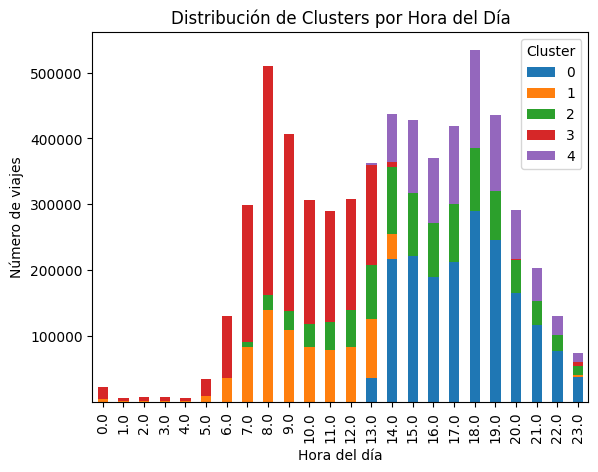

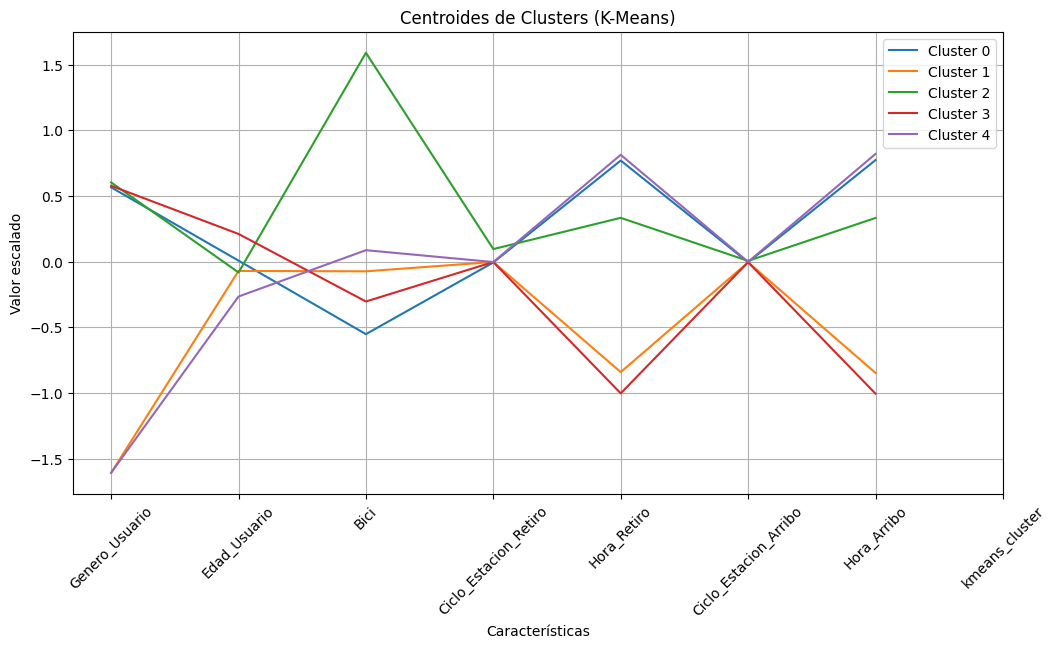

In [2]:
import pandas as pd
import dask.dataframe as dd
from tkinter import Tk, filedialog
from tkinter.filedialog import askopenfilename
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

def select_csv_file():
    """Selecciona un archivo CSV """
    Tk().withdraw()
    return askopenfilename(
        title="Seleccionar archivo CSV de ECOBICI",
        filetypes=[("CSV", "*.csv"), ("Todos", "*.*")]
    )

def convert_to_parquet(csv_path):
    """Convertimos a parquet para mejor rendimiento"""
    print("Leyendo archivo CSV (esto puede tomar varios minutos)...")
    ddf = dd.read_csv(csv_path, assume_missing=True)
    
    parquet_path = csv_path.replace('.csv', '.parquet')
    print(f"Convirtiendo a Parquet en: {parquet_path}")
    ddf.to_parquet(parquet_path, engine='pyarrow')
    print("✅ Conversión completada")
    return parquet_path

def create_tad(parquet_path):
    """Crea la Tabla Analítica de Datos."""
    print(" Creando Tabla Analítica de Datos (TAD)...")
    ddf = dd.read_parquet(parquet_path)
    
    # Transformación de datos basada en tu estructura
    # Convertir horas de string a numéricas (extraer solo la hora)
    if 'Hora_Retiro' in ddf.columns:
        ddf['Hora_Retiro'] = ddf['Hora_Retiro'].str.split(':').str[0].astype(float)
    if 'Hora_Arribo' in ddf.columns:
        ddf['Hora_Arribo'] = ddf['Hora_Arribo'].str.split(':').str[0].astype(float)
    
    # Eliminar columnas no relevantes o duplicadas
    columns_to_keep = [
        'Genero_Usuario', 
        'Edad_Usuario', 
        'Bici', 
        'Ciclo_Estacion_Retiro',
        'Hora_Retiro',
        'Ciclo_Estacion_Arribo',
        'Hora_Arribo'
    ]
    
    tad = ddf[columns_to_keep]
    print("✅ TAD creada exitosamente")
    return tad

def train_models(tad, sample_size=0.1):
    """Entrena modelos de clustering con muestra de datos y muestra resultados ."""
    print(" Entrenando modelos de clustering...")
    
    # Muestrear datos para entrenamiento
    sample = tad.sample(frac=sample_size, random_state=42).compute()
    print("\n Muestra de la TAD (primeras 5 filas):")
    print(sample.head())
    
    # Escalar datos
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(sample.select_dtypes(include=['number']))
    
    # Entrenar K-Means
    print("\n K-Means clustering:")
    kmeans = MiniBatchKMeans(n_clusters=5, batch_size=1000, random_state=42)
    kmeans.fit(scaled_data)
    print("  - Inercia:", kmeans.inertia_)
    print("  - Conteo de puntos por cluster:")
    print(pd.Series(kmeans.labels_).value_counts().sort_index())
    
    # Entrenar Gaussian Mixture
    print("\n Gaussian Mixture Model:")
    gmm = GaussianMixture(n_components=5, random_state=42)
    gmm.fit(scaled_data)
    print("  - Log-likelihood:", gmm.lower_bound_)
    print("  - Conteo de puntos por cluster (predicción):")
    gmm_labels = gmm.predict(scaled_data)
    print(pd.Series(gmm_labels).value_counts().sort_index())
    
    # Entrenar Agglomerative Clustering (submuestra)
    print("\n Agglomerative Clustering (submuestra de 10,000 puntos):")
    agg = AgglomerativeClustering(n_clusters=5)
    agg_labels = agg.fit_predict(scaled_data[:10000])
    print("  - Conteo de puntos por cluster:")
    print(pd.Series(agg_labels).value_counts().sort_index())
    
    return {
        'kmeans': kmeans,
        'gmm': gmm,
        'agg': agg,
        'sample': sample,
        'scaled_data': scaled_data
    }

def profile_by_time(sample, models):
    """Realiza perfilamiento por tiempo."""
    print(" Realizando perfilamiento por tiempo...")
    
    # Agregar clusters al dataframe
    sample['kmeans_cluster'] = models['kmeans'].labels_
    
    # Extraer componentes de tiempo si estuvieran disponibles
    # En este caso usaremos Hora_Retiro
    time_profile = sample.groupby(['Hora_Retiro', 'kmeans_cluster']).size().unstack()
    
    return time_profile

def plot_time_profile(time_profile):
    """Visualiza el perfil temporal de clusters."""
    plt.figure(figsize=(12, 6))
    time_profile.fillna(0).plot(kind='bar', stacked=True)
    plt.title('Distribución de Clusters por Hora del Día')
    plt.xlabel('Hora del día')
    plt.ylabel('Número de viajes')
    plt.legend(title='Cluster')
    plt.show()

def plot_cluster_centers(centers, feature_names):
    """Visualiza los centroides de los clusters."""
    plt.figure(figsize=(12, 6))
    for i in range(centers.shape[0]):
        plt.plot(centers[i], label=f'Cluster {i}')
    plt.xticks(range(len(feature_names)), feature_names, rotation=45)
    plt.title('Centroides de Clusters (K-Means)')
    plt.xlabel('Características')
    plt.ylabel('Valor escalado')
    plt.legend()
    plt.grid()
    plt.show()

def main():
    # Paso 1: Selección y conversión de archivo
    csv_path = select_csv_file()
    if not csv_path:
        print("❌ No se seleccionó ningún archivo")
        return
    
    parquet_path = convert_to_parquet(csv_path)
    
    # Paso 2: Crear TAD
    tad = create_tad(parquet_path)
    
    # Paso 3: Entrenar modelos (usando 5% de muestra para velocidad)
    models = train_models(tad, sample_size=0.05)
    
    # Paso 4: Perfilamiento por tiempo
    time_profile = profile_by_time(models['sample'], models)
    
    # Resultados
    print("\n=== RESULTADOS ===")
    print("\nDistribución de clusters por hora:")
    print(time_profile.head(24))  # Mostrar las 24 horas
    
    print("\nCentroides de clusters (K-Means):")
    print(models['kmeans'].cluster_centers_)
    
    # Visualizaciones adicionales
    print("\n Generando visualizaciones...")
    
    # 1. Perfil temporal
    plot_time_profile(time_profile)
    
    # 2. Centroides de clusters
    feature_names = models['sample'].select_dtypes(include=['number']).columns.tolist()
    plot_cluster_centers(models['kmeans'].cluster_centers_, feature_names)

if __name__ == "__main__":
    main()

**Distribución de Clusters por Hora**

**Observaciones:**

**luster 3** domina el uso entre las **6:00 a 13:00 hrs**, lo que podría reflejar usuarios que viajan al trabajo o a la escuela.
**Cluster 0 y Cluster 4** son dominantes en las horas vespertinas y nocturnas **(14:00–21:00)**, probablemente vinculados al regreso o actividades recreativas.
**Cluster 1** aparece principalmente en la madrugada **(0:00–6:00)**, lo que puede indicar un perfil de usuario más activo en horarios no convencionales.

**Centroides de Clusters**

**Observaciones:**

**Cluster 2** se asocia con valores extremadamente altos en la variable **Bici**, lo que puede indicar un grupo de usuarios con patrones específicos o bicicletas de uso intensivo.
**Cluster 1 y 4** presentan valores negativos altos en **Genero_Usuario**, posiblemente asociados a usuarios que no especificaron género o son minoría.
**Cluster 3** tiene valores bajos en **Hora_Retiro y Hora_Arribo**, indicando uso temprano en el día.
**Cluster 0** está asociado con usuarios de **edad promedio, género predominante masculino y viajes en horas vespertinas**.

**El sistema ECOBICI presenta patrones de uso claramente diferenciables por hora del día**
